In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path.cwd() / 'data'
if not DATA_DIR.exists():
    DATA_DIR = Path.cwd().parent / 'data'

pss_2122 = pd.read_csv(DATA_DIR / 'pss_2021-22.csv')
pss_1920 = pd.read_csv(DATA_DIR / 'pss_2019-20.csv')
merge_hs_econ = pd.read_csv(DATA_DIR / 'merge_hs_econ.csv')

print('pss_2122:', pss_2122.shape)
print('pss_1920:', pss_1920.shape)
print('merge_hs_econ:', merge_hs_econ.shape)


/var/folders/wz/pjx159kj141cgdkvkdrlfb040000gn/T/ipykernel_71665/2794723602.py:8: DtypeWarning: Columns (0: PPIN, 1: SLDUST22) have mixed types. Specify dtype option on import or set low_memory=False.
  pss_2122 = pd.read_csv(DATA_DIR / 'pss_2021-22.csv')
/var/folders/wz/pjx159kj141cgdkvkdrlfb040000gn/T/ipykernel_71665/2794723602.py:9: DtypeWarning: Columns (0: SLDLST20, 1: SLDUST20) have mixed types. Specify dtype option on import or set low_memory=False.
  pss_1920 = pd.read_csv(DATA_DIR / 'pss_2019-20.csv')


pss_2122: (22345, 459)
pss_1920: (21572, 349)
merge_hs_econ: (1048575, 38)


In [2]:
# Keep only the PSS columns we need
pss_keep_cols = ['PPIN', 'LEVEL', 'PINST', 'PCNTY', 'PSTABB']

pss_2122_small = pss_2122[pss_keep_cols].copy()
pss_1920_small = pss_1920[pss_keep_cols].copy()

for df in [pss_2122_small, pss_1920_small]:
    df['PPIN'] = df['PPIN'].astype('string').str.strip()

pss_2122_small.head()

,PPIN,LEVEL,PINST,PCNTY,PSTABB
0,33,1,ST JAMES CATHOLIC SCHOOL,55,AL
1,44,3,HOLY SPIRIT CATHOLIC SCHOOL,125,AL
2,55,1,HOLY FAMILY PAROCHIAL SCHOOL,89,AL
3,77,1,HOLY SPIRIT REGIONAL CATHOLIC SCHOOL,89,AL
4,88,1,OUR LADY OF SORROWS,73,AL


In [3]:
# Merge PSS into merge_hs_econ by hs_id (PPIN) for the requested year ranges
merge_hs_econ['hs_id'] = merge_hs_econ['hs_id'].astype('string').str.strip()
merge_hs_econ['cycle'] = pd.to_numeric(merge_hs_econ['cycle'], errors='coerce').astype('Int64')

private_mask = merge_hs_econ['school_type'].astype('string') == 'private'

years_2122 = [2021, 2022, 2023]
years_1920 = [2019, 2020]

base = merge_hs_econ.copy()
base['_row_id'] = range(len(base))

# 2021-2023 from 2021-22 PSS
m_2122 = (
    base.loc[private_mask & base['cycle'].isin(years_2122), ['_row_id', 'hs_id', 'cycle']]
      .merge(pss_2122_small, left_on='hs_id', right_on='PPIN', how='left')
      .set_index('_row_id')
)

# 2019-2020 from 2019-20 PSS
m_1920 = (
    base.loc[private_mask & base['cycle'].isin(years_1920), ['_row_id', 'hs_id', 'cycle']]
      .merge(pss_1920_small, left_on='hs_id', right_on='PPIN', how='left')
      .set_index('_row_id')
)

# Attach PSS columns back to the full dataset
pss_cols = pss_keep_cols
for c in pss_cols:
    base[c] = pd.NA

for c in pss_cols:
    base.loc[m_2122.index, c] = m_2122[c].values
    base.loc[m_1920.index, c] = m_1920[c].values

merge_hs_econ_with_pss = base.drop(columns=['_row_id'])

print('merge_hs_econ_with_pss shape:', merge_hs_econ_with_pss.shape)
print('PSS matched rows (2122 years):', merge_hs_econ_with_pss.loc[private_mask & merge_hs_econ_with_pss['cycle'].isin(years_2122) & merge_hs_econ_with_pss['PPIN'].notna()].shape[0])
print('PSS matched rows (1920 years):', merge_hs_econ_with_pss.loc[private_mask & merge_hs_econ_with_pss['cycle'].isin(years_1920) & merge_hs_econ_with_pss['PPIN'].notna()].shape[0])

merge_hs_econ_with_pss.loc[private_mask, ['cycle', 'hs_id'] + pss_keep_cols].head()

merge_hs_econ_with_pss shape: (1048575, 43)
PSS matched rows (2122 years): 70363
PSS matched rows (1920 years): 102107


,cycle,hs_id,PPIN,LEVEL,PINST,PCNTY,PSTABB
1,2023,A1900014,A1900014,3.0,EASTWOOD CHRISTIAN SCHOOL,101.0,AL
8,2020,00348046,00348046,2,ROSARY HIGH SCHOOL,89,IL
9,2019,01922884,01922884,1,OUR LADY QUEEN OF HEAVEN SCHOOL,19,LA
13,2022,01899977,01899977,1.0,DEL MAR PINES SCHOOL,73.0,CA
15,2021,01325662,<NA>,NaN,NaN,NaN,NaN


In [4]:
# Missingness after merging (overall + by year)
pss_cols = ['PPIN', 'LEVEL', 'PINST', 'PCNTY', 'PSTABB']

private_df = merge_hs_econ_with_pss.loc[merge_hs_econ_with_pss['school_type'].astype('string') == 'private'].copy()
private_df['cycle'] = pd.to_numeric(private_df['cycle'], errors='coerce').astype('Int64')

# Overall: fraction of private rows with any PSS match (PPIN present)
overall_match_rate = private_df['PPIN'].notna().mean() * 100
print(f"Overall PSS match rate (private rows): {overall_match_rate:.2f}%")

# Overall missingness per PSS column
overall_missing = (1 - private_df[pss_cols].notna().mean()).mul(100).round(2)
print('Overall % missing by PSS column:')
display(overall_missing)

# By year: match rate and missingness
by_year = private_df.groupby('cycle').apply(
    lambda g: pd.Series({
        'n_rows': len(g),
        'match_rate_pct': g['PPIN'].notna().mean() * 100,
        **{f"missing_{c}_pct": (1 - g[c].notna().mean()) * 100 for c in pss_cols},
    })
).round(2).sort_index()
by_year

Overall PSS match rate (private rows): 70.47%
Overall % missing by PSS column:


PPIN      29.53
LEVEL     29.53
PINST     29.53
PCNTY     29.53
PSTABB    29.53
dtype: float64

,n_rows,match_rate_pct,missing_PPIN_pct,missing_LEVEL_pct,missing_PINST_pct,missing_PCNTY_pct,missing_PSTABB_pct
cycle,,,,,,,
2019,63898.0,100.00,0.00,0.00,0.00,0.00,0.00
2020,38209.0,100.00,0.00,0.00,0.00,0.00,0.00
2021,46159.0,49.16,50.84,50.84,50.84,50.84,50.84
2022,54634.0,49.14,50.86,50.86,50.86,50.86,50.86
2023,41850.0,49.76,50.24,50.24,50.24,50.24,50.24


In [5]:
# Frequency distribution of LEVEL (1=Elementary, 2=Secondary, 3=Combined)
level_map = {1: 'Elementary', 2: 'Secondary', 3: 'Combined'}

level_df = private_df.copy()
level_df['LEVEL_num'] = pd.to_numeric(level_df['LEVEL'], errors='coerce')

level_counts = level_df['LEVEL_num'].value_counts(dropna=False).sort_index()
level_pct = (level_counts / len(level_df) * 100).round(2)

level_summary = pd.DataFrame({
    'count': level_counts,
    'pct': level_pct,
})
level_summary.index = level_summary.index.map(lambda x: level_map.get(int(x), 'Missing/Other') if pd.notna(x) else 'Missing')

print('Elementary-only (LEVEL==1) %:', float(level_pct.get(1, 0)))
level_summary

Elementary-only (LEVEL==1) %: 41.85


,count,pct
LEVEL_num,,
Elementary,102430,41.85
Secondary,19669,8.04
Combined,50371,20.58
Missing,72280,29.53


In [6]:
# Match PSS 2019-20 to private schools for cycles 2019-2023 and check match rate
years = [2019, 2020, 2021, 2022, 2023]

main_private = merge_hs_econ.copy()
main_private['hs_id'] = main_private['hs_id'].astype('string').str.strip()
main_private['cycle'] = pd.to_numeric(main_private['cycle'], errors='coerce').astype('Int64')
main_private = main_private.loc[(main_private['school_type'].astype('string') == 'private') & (main_private['cycle'].isin(years))].copy()

pss_1920_small['PPIN'] = pss_1920_small['PPIN'].astype('string').str.strip()

main_private_pss1920 = main_private.merge(
    pss_1920_small,
    left_on='hs_id',
    right_on='PPIN',
    how='left',
    suffixes=('', '_pss1920')
)

overall_match_rate = main_private_pss1920['PPIN'].notna().mean() * 100
print('Years:', years)
print(f"Overall PSS 2019-20 match rate (private rows, 2019-2023): {overall_match_rate:.2f}%")

by_year = main_private_pss1920.groupby('cycle')['PPIN'].apply(lambda s: s.notna().mean() * 100).round(2)
by_year

Years: [2019, 2020, 2021, 2022, 2023]
Overall PSS 2019-20 match rate (private rows, 2019-2023): 100.00%


cycle
2019    100.0
2020    100.0
2021    100.0
2022    100.0
2023    100.0
Name: PPIN, dtype: float64

In [7]:
# LEVEL distribution from the PSS 2019-20 merge (1=Elementary, 2=Secondary, 3=Combined)
level_map = {1: 'Elementary', 2: 'Secondary', 3: 'Combined'}

df_lvl = main_private_pss1920.copy()
df_lvl['LEVEL_num'] = pd.to_numeric(df_lvl['LEVEL'], errors='coerce')

counts_all = df_lvl['LEVEL_num'].value_counts(dropna=False).sort_index()
pct_all = (counts_all / len(df_lvl) * 100).round(2)
level_dist_all = pd.DataFrame({'count': counts_all, 'pct': pct_all})
level_dist_all.index = level_dist_all.index.map(lambda x: level_map.get(int(x), 'Missing/Other') if pd.notna(x) else 'Missing')

print('LEVEL distribution (all private rows 2019-2023; unmatched show as Missing):')
display(level_dist_all)

df_lvl_matched = df_lvl.loc[df_lvl['PPIN'].notna()].copy()
counts_m = df_lvl_matched['LEVEL_num'].value_counts(dropna=False).sort_index()
pct_m = (counts_m / len(df_lvl_matched) * 100).round(2) if len(df_lvl_matched) else counts_m
level_dist_matched = pd.DataFrame({'count': counts_m, 'pct': pct_m})
level_dist_matched.index = level_dist_matched.index.map(lambda x: level_map.get(int(x), 'Missing/Other') if pd.notna(x) else 'Missing')

print('LEVEL distribution (matched only):')
level_dist_matched

LEVEL distribution (all private rows 2019-2023; unmatched show as Missing):


,count,pct
LEVEL_num,,
Elementary,148810,60.80
Secondary,30756,12.57
Combined,65184,26.63


LEVEL distribution (matched only):


,count,pct
LEVEL_num,,
Elementary,148810,60.80
Secondary,30756,12.57
Combined,65184,26.63


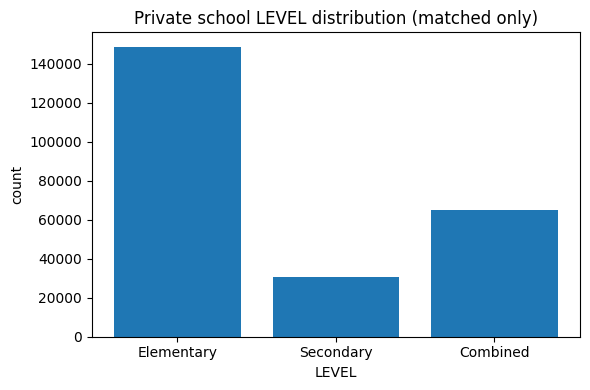

In [9]:
# Bar chart: LEVEL distribution (matched only)
import matplotlib.pyplot as plt

level_map = {1: 'Elementary', 2: 'Secondary', 3: 'Combined'}

df_lvl = main_private_pss1920.loc[main_private_pss1920['PPIN'].notna()].copy()
df_lvl['LEVEL_num'] = pd.to_numeric(df_lvl['LEVEL'], errors='coerce')

counts = df_lvl['LEVEL_num'].value_counts().reindex([1, 2, 3])
labels = [level_map[i] for i in [1, 2, 3]]
values = counts.fillna(0).astype(int).tolist()

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.title('Private school LEVEL distribution (matched only)')
plt.xlabel('LEVEL')
plt.ylabel('count')
plt.tight_layout()
plt.show()